In [1]:
pip install pandas scikit-learn


[notice] A new release of pip is available: 23.3.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd

# 1. Load dataset
df = pd.read_csv("stock_tweets.csv")

print(df.head())

# 2. Keep only text column
df = df[['Tweet']]

# 3. Create simple sentiment (rule-based)
def get_sentiment(text):
    text = text.lower()
    
    if "good" in text or "profit" in text or "gain" in text:
        return 1   # positive
    elif "bad" in text or "loss" in text or "fall" in text:
        return 0   # negative
    else:
        return 2   # neutral

df['Sentiment'] = df['Tweet'].apply(get_sentiment)

print(df.head())

# 4. Convert text into numbers
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer()
X = vectorizer.fit_transform(df['Tweet'])

y = df['Sentiment']

# 5. Train model
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

from sklearn.naive_bayes import MultinomialNB
model = MultinomialNB()

model.fit(X_train, y_train)

# 6. Prediction
y_pred = model.predict(X_test)

# 7. Accuracy
from sklearn.metrics import accuracy_score
print("Accuracy:", accuracy_score(y_test, y_pred))

                        Date  \
0  2022-09-29 23:41:16+00:00   
1  2022-09-29 23:24:43+00:00   
2  2022-09-29 23:18:08+00:00   
3  2022-09-29 22:40:07+00:00   
4  2022-09-29 22:27:05+00:00   

                                               Tweet Stock Name Company Name  
0  Mainstream media has done an amazing job at br...       TSLA  Tesla, Inc.  
1  Tesla delivery estimates are at around 364k fr...       TSLA  Tesla, Inc.  
2  3/ Even if I include 63.0M unvested RSUs as of...       TSLA  Tesla, Inc.  
3  @RealDanODowd @WholeMarsBlog @Tesla Hahaha why...       TSLA  Tesla, Inc.  
4  @RealDanODowd @Tesla Stop trying to kill kids,...       TSLA  Tesla, Inc.  
                                               Tweet  Sentiment
0  Mainstream media has done an amazing job at br...          2
1  Tesla delivery estimates are at around 364k fr...          2
2  3/ Even if I include 63.0M unvested RSUs as of...          2
3  @RealDanODowd @WholeMarsBlog @Tesla Hahaha why...          2
4  @RealDanOD

In [5]:
import pandas as pd

In [6]:
df = pd.read_csv("stock_tweets.csv")
df

,Date,Tweet,Stock Name,Company Name
0,2022-09-29 23:41:16+00:00,Mainstream media has done an amazing job at br...,TSLA,"Tesla, Inc."
1,2022-09-29 23:24:43+00:00,Tesla delivery estimates are at around 364k fr...,TSLA,"Tesla, Inc."
2,2022-09-29 23:18:08+00:00,3/ Even if I include 63.0M unvested RSUs as of...,TSLA,"Tesla, Inc."
3,2022-09-29 22:40:07+00:00,@RealDanODowd @WholeMarsBlog @Tesla Hahaha why...,TSLA,"Tesla, Inc."
4,2022-09-29 22:27:05+00:00,"@RealDanODowd @Tesla Stop trying to kill kids,...",TSLA,"Tesla, Inc."
...,...,...,...,...
80788,2021-10-07 17:11:57+00:00,Some of the fastest growing tech stocks on the...,XPEV,XPeng Inc.
80789,2021-10-04 17:05:59+00:00,"With earnings on the horizon, here is a quick ...",XPEV,XPeng Inc.
80790,2021-10-01 04:43:41+00:00,Our record delivery results are a testimony of...,XPEV,XPeng Inc.
80791,2021-10-01 00:03:32+00:00,"We delivered 10,412 Smart EVs in Sep 2021, rea...",XPEV,XPeng Inc.


In [8]:
print(df.head())

                        Date  \
0  2022-09-29 23:41:16+00:00   
1  2022-09-29 23:24:43+00:00   
2  2022-09-29 23:18:08+00:00   
3  2022-09-29 22:40:07+00:00   
4  2022-09-29 22:27:05+00:00   

                                               Tweet Stock Name Company Name  
0  Mainstream media has done an amazing job at br...       TSLA  Tesla, Inc.  
1  Tesla delivery estimates are at around 364k fr...       TSLA  Tesla, Inc.  
2  3/ Even if I include 63.0M unvested RSUs as of...       TSLA  Tesla, Inc.  
3  @RealDanODowd @WholeMarsBlog @Tesla Hahaha why...       TSLA  Tesla, Inc.  
4  @RealDanODowd @Tesla Stop trying to kill kids,...       TSLA  Tesla, Inc.  


In [9]:
df = df[['Tweet']]


In [10]:
def get_sentiment(text):
    text = text.lower()
    
    if "good" in text or "profit" in text or "gain" in text:
        return 1   # positive
    elif "bad" in text or "loss" in text or "fall" in text:
        return 0   # negative
    else:
        return 2   # neutral


In [18]:
df['Sentiment'] = df['Tweet'].apply(get_sentiment)

print(df.head())


                                               Tweet  Sentiment
0  Mainstream media has done an amazing job at br...          2
1  Tesla delivery estimates are at around 364k fr...          2
2  3/ Even if I include 63.0M unvested RSUs as of...          2
3  @RealDanODowd @WholeMarsBlog @Tesla Hahaha why...          2
4  @RealDanODowd @Tesla Stop trying to kill kids,...          2


/tmp/ipykernel_6527/204442072.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Sentiment'] = df['Tweet'].apply(get_sentiment)


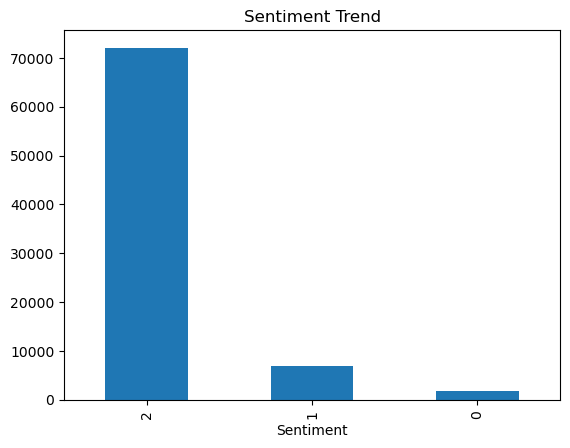

In [19]:
import matplotlib.pyplot as plt

df['Sentiment'].value_counts().plot(kind='bar')
plt.title("Sentiment Trend")
plt.show()

In [13]:
from sklearn.feature_extraction.text import CountVectorizer
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(df['Tweet'])

y = df['Sentiment']


In [14]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

from sklearn.naive_bayes import MultinomialNB
model = MultinomialNB()

In [15]:
model.fit(X_train, y_train)

MultinomialNB()

In [16]:
y_pred = model.predict(X_test)

In [17]:
from sklearn.metrics import accuracy_score
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9335354910576149


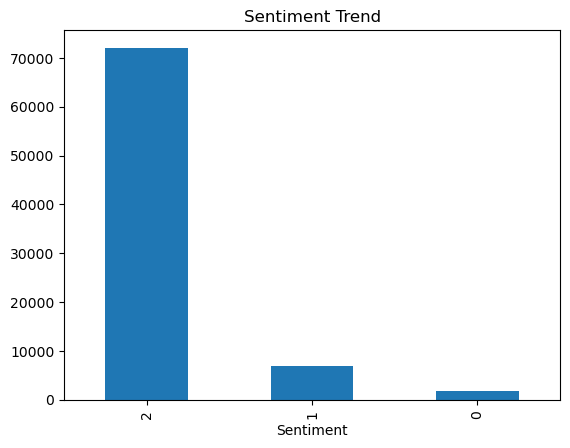